# 🧪 FTIR Analysis Notebook
This notebook performs FTIR data loading, preprocessing, smoothing, and peak detection.

### 1. **Raw FTIR Spectrum Visualization**
This section visualizes the raw FTIR spectrum before any preprocessing steps.
Plotting the original signal helps in understanding:


*   The overall shape of the spectrum
*   Noise level in the data
*   Presence of broad or sharp peaks
*   Regions that may require smoothing or baseline correction

The raw plot serves as the baseline reference for all subsequent processing steps.





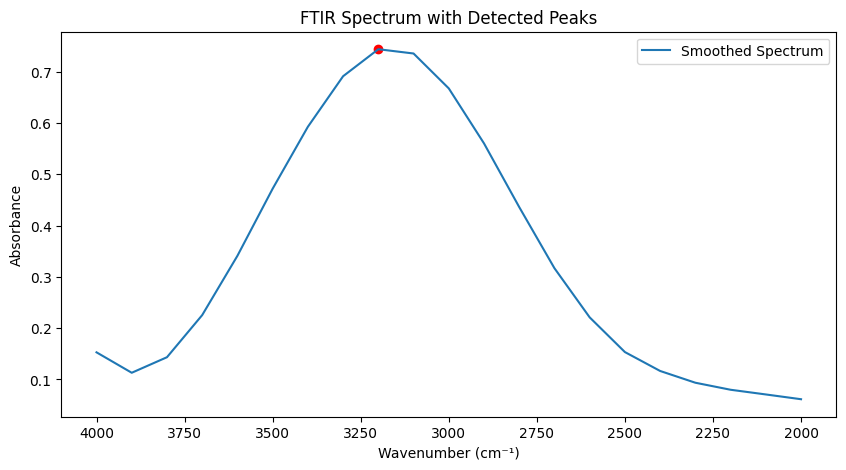

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks

# Load FTIR data
data = pd.read_csv('ftir-analysis/data/sample_ftir.csv')

wavenumber = data['Wavenumber']
absorbance = data['Absorbance']

# Smoothing
smooth = savgol_filter(absorbance, window_length=11, polyorder=3)

# Peak detection
peaks, _ = find_peaks(smooth, height=0.05)

# Plot
plt.figure(figsize=(10,5))
plt.plot(wavenumber, smooth, label='Smoothed Spectrum')
plt.scatter(wavenumber[peaks], smooth[peaks], color='red')
plt.gca().invert_xaxis()
plt.xlabel('Wavenumber (cm⁻¹)')
plt.ylabel('Absorbance')
plt.title('FTIR Spectrum with Detected Peaks')
plt.legend()
plt.show()

In [ ]:
!git clone https://github.com/atheermq/ftir-analysis.git


fatal: destination path 'ftir-analysis' already exists and is not an empty directory.


### 2.** Upload FTIR Data File**
In this step, the FTIR dataset is uploaded directly into the notebook using the files.upload() function.
This method allows the user to manually select a CSV file from their local device.
Uploading the file ensures that the data is available in the Colab environment for further processing and analysis.

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving sample_ftir.csv to sample_ftir (1).csv


### **3. Load FTIR Dataset**
In this step, the FTIR data file (sample_ftir.csv) is loaded into a pandas DataFrame.
Displaying the first few rows using data.head() allows us to:


*  Verify that the file was uploaded correctly
*  Check column names and data structure
*  Ensure that the wavenumber and absorbance values are properly formatted
*  Confirm that the dataset is ready for preprocessing and analysis

This step is essential before applying smoothing, peak detection, or any further signal processing.

In [ ]:
import pandas as pd

data = pd.read_csv('sample_ftir.csv')
data.head()


,Wavenumber,Absorbance
0,4000,0.12
1,3900,0.15
2,3800,0.18
3,3700,0.22
4,3600,0.30


### **4. Check Dataset Dimensions**
This step displays the shape of the loaded FTIR dataset using data.shape.
Understanding the dataset dimensions helps verify:

*  The number of rows (data points in the spectrum)
*  The number of columns (typically wavenumber and absorbance)
*  Whether the file was loaded correctly
*  If the dataset is complete and ready for preprocessing

This quick check ensures that the structure of the data matches the expected FTIR format before moving forward.

In [ ]:
data.shape


(21, 2)

### **5. Plotting the Raw FTIR Spectrum**
This step visualizes the raw FTIR signal before applying any preprocessing or smoothing techniques.
Plotting the spectrum at this stage helps in:
*  Understanding the overall shape of the signal
*  Identifying noise levels and irregularities
*  Locating major absorption peaks
*  Determining whether baseline correction or smoothing is needed
*  Establishing a visual reference for all subsequent processing steps

The raw plot serves as the foundation for peak detection, derivative analysis, and feature extraction.

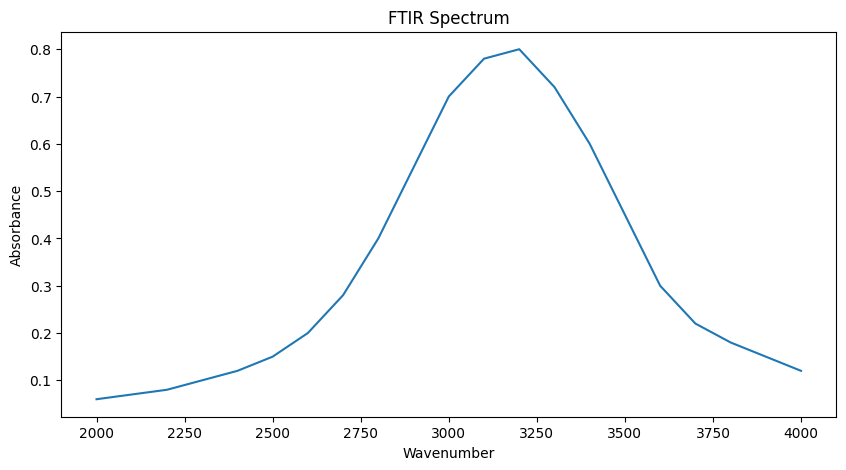

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(data.iloc[:,0], data.iloc[:,1])
plt.xlabel('Wavenumber')
plt.ylabel('Absorbance')
plt.title('FTIR Spectrum')
plt.show()


### **6. Peak Detection Using find_peaks**
In this step, the FTIR spectrum is analyzed to automatically detect absorption peaks using the find_peaks function from scipy.signal.
Peak detection is a critical part of FTIR analysis because peaks correspond to specific molecular vibrations and functional groups.

This step extracts:
*  Peak positions (wavenumbers where absorption occurs)
*  Peak heights (intensity of absorption)

A height threshold of 0.05 is used to filter out noise and ensure that only meaningful peaks are detected.
These detected peaks will be used later for derivative analysis, peak interpretation, and feature extraction.

In [ ]:
import numpy as np
from scipy.signal import find_peaks

# استخراج القمم
y = data.iloc[:,1].values
peaks, _ = find_peaks(y, height=0.05)  # تقدرين تغيرين threshold حسب شدة الإشارة

# عرض مواقع القمم
peak_positions = data.iloc[peaks, 0].values
peak_heights = data.iloc[peaks, 1].values

peak_positions, peak_heights


(array([3200]), array([0.8]))

### **7. Visualizing Detected Peaks on the FTIR Spectrum**
This plot overlays the detected peaks on top of the raw FTIR spectrum.
Highlighting the peaks visually helps in:
*  Confirming that the peak detection algorithm identified the correct absorption points
*  Distinguishing true peaks from noise
*  Understanding the intensity and sharpness of each peak
*  Preparing for further analysis such as derivatives, FWHM, and functional group interpretation

The red markers represent the peak positions and their corresponding absorbance values.

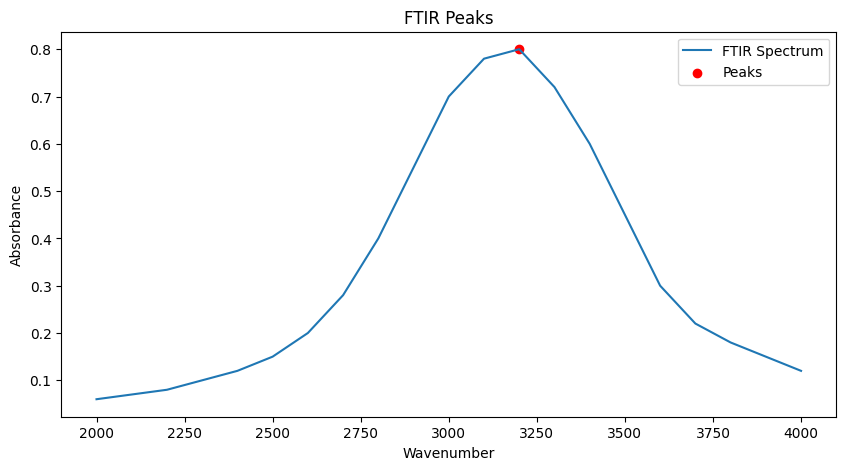

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(data.iloc[:,0], data.iloc[:,1], label='FTIR Spectrum')
plt.scatter(peak_positions, peak_heights, color='red', label='Peaks')
plt.xlabel('Wavenumber')
plt.ylabel('Absorbance')
plt.title('FTIR Peaks')
plt.legend()
plt.show()


### **8. Smoothing the FTIR Spectrum (Savitzky–Golay Filter)**
To reduce noise and enhance the clarity of the FTIR signal, the Savitzky–Golay smoothing filter is applied.
This method preserves important spectral features such as peak height, width, and position while removing high‑frequency noise.

Key benefits of smoothing:
*  Improves peak visibility
*  Reduces random fluctuations in the signal
*  Prepares the data for accurate peak detection and derivative analysis
*  Maintains the original shape of the spectrum without distortion

A window length of 11 and polynomial order of 3 are used, which provide a balanced level of smoothing without over‑flattening the peaks.

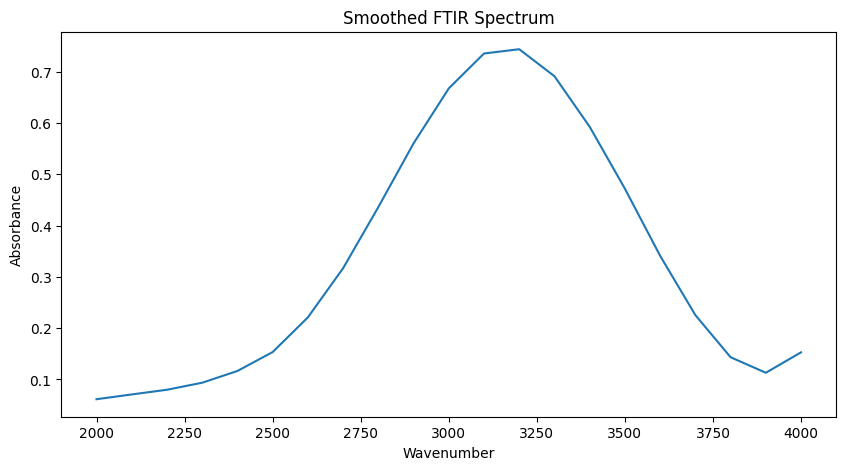

In [ ]:
from scipy.signal import savgol_filter

smoothed = savgol_filter(data.iloc[:,1], window_length=11, polyorder=3)

plt.figure(figsize=(10,5))
plt.plot(data.iloc[:,0], smoothed)
plt.title("Smoothed FTIR Spectrum")
plt.xlabel("Wavenumber")
plt.ylabel("Absorbance")
plt.show()


### **9. Functional Group Interpretation of Detected Peaks**
After detecting the peak positions, this step assigns a chemical meaning to each peak based on well‑known FTIR absorption ranges.
Each wavenumber corresponds to a specific molecular vibration, allowing us to identify functional groups present in the sample.

This interpretation helps in:
*  Understanding the chemical structure of the material
*  Linking spectral peaks to molecular bonds
*  Identifying characteristic groups such as O–H, C–H, C=O, and C–O
*  Providing a chemical explanation for the detected peaks

The code below compares each peak position with standard FTIR ranges and returns the most likely functional group assignment.

In [ ]:
# تفسير القمم بناءً على نطاقات FTIR الشائعة
interpretation = []

for peak in peak_positions:
    if 3200 <= peak <= 3600:
        interpretation.append((peak, "O-H Stretch (Alcohols, Phenols)"))
    elif 3000 <= peak <= 3100:
        interpretation.append((peak, "C-H Stretch (Aromatic)"))
    elif 2850 <= peak <= 2960:
        interpretation.append((peak, "C-H Stretch (Alkanes)"))
    elif 1650 <= peak <= 1750:
        interpretation.append((peak, "C=O Stretch (Carbonyls)"))
    elif 1500 <= peak <= 1600:
        interpretation.append((peak, "C=C Aromatic Stretch"))
    elif 1000 <= peak <= 1300:
        interpretation.append((peak, "C-O Stretch (Alcohols, Esters, Ethers)"))
    else:
        interpretation.append((peak, "Unassigned / Other Functional Group"))

interpretation


[(np.int64(3200), 'O-H Stretch (Alcohols, Phenols)')]

### **10. First Derivative of the FTIR Spectrum**
The first derivative of the FTIR spectrum is calculated to highlight subtle changes in absorbance and reveal hidden peaks that may not be visible in the raw or smoothed signal.
This technique is commonly used in spectral analysis to:
*  Enhance resolution between overlapping peaks
*  Identify inflection points corresponding to peak boundaries
*  Improve baseline correction and noise differentiation
*  Prepare data for advanced analysis such as second derivative or PCA

By plotting the first derivative, we can observe how the rate of change in absorbance varies across wavenumbers, providing deeper insight into the spectral features.

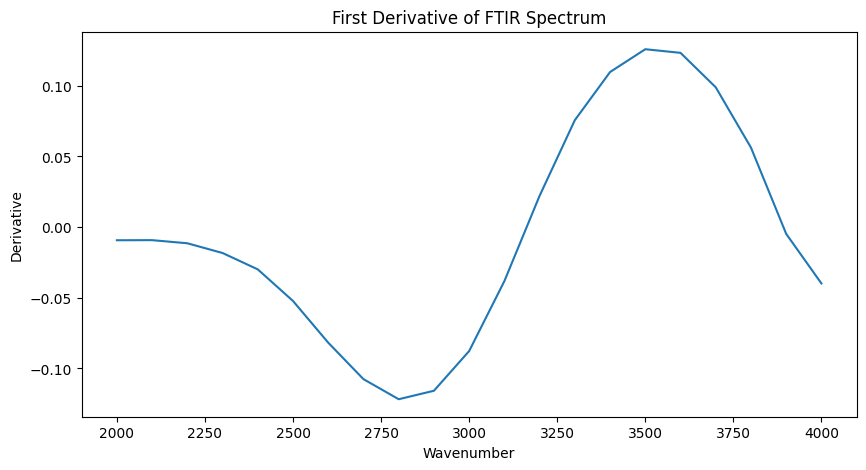

In [ ]:
import numpy as np

first_derivative = np.gradient(smoothed)

plt.figure(figsize=(10,5))
plt.plot(data.iloc[:,0], first_derivative)
plt.title("First Derivative of FTIR Spectrum")
plt.xlabel("Wavenumber")
plt.ylabel("Derivative")
plt.show()


### **11. Second Derivative of the FTIR Spectrum**
The second derivative of the FTIR spectrum provides enhanced peak resolution and helps separate overlapping peaks that may not be distinguishable in the raw or smoothed signal.
This technique is widely used in advanced spectral analysis because it:
*  Sharpens peak features and improves visibility
*  Highlights subtle changes in curvature
*  Helps distinguish closely spaced or overlapping peaks
*  Reduces baseline effects more effectively than the first derivative
*  Supports more accurate peak interpretation and functional group identification

By plotting the second derivative, we obtain a clearer view of the underlying spectral structure, making it easier to analyze complex or noisy FTIR signals.

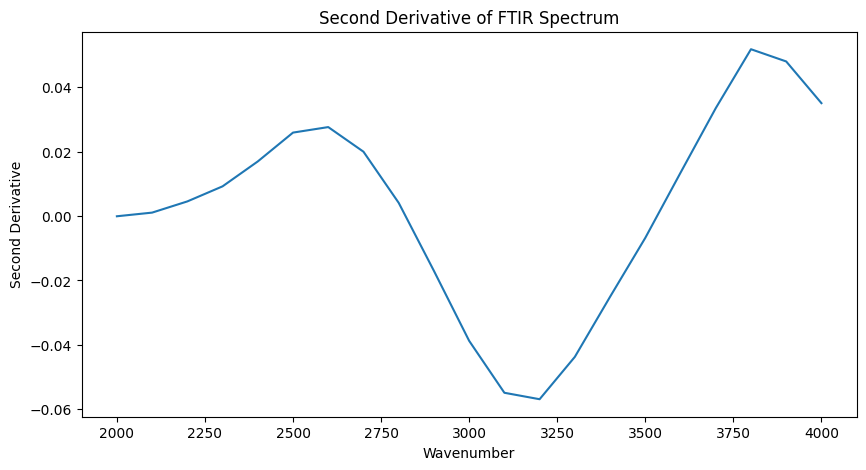

In [ ]:
second_derivative = np.gradient(first_derivative)

plt.figure(figsize=(10,5))
plt.plot(data.iloc[:,0], second_derivative)
plt.title("Second Derivative of FTIR Spectrum")
plt.xlabel("Wavenumber")
plt.ylabel("Second Derivative")
plt.show()


### **12. Calculating the Area Under the Smoothed FTIR Spectrum**
In this step, the total area under the smoothed FTIR curve is calculated using the trapezoidal integration method (trapz).
This numerical integration provides a quantitative measure of the overall absorbance intensity across the entire wavenumber range.

Why this step is useful:
*  It summarizes the entire FTIR signal into a single numerical value
*  Helps compare different samples based on total absorbance
*  Useful for concentration estimation or semi‑quantitative analysis
*  Provides a baseline metric for further statistical or machine‑learning steps

The integration is performed on the smoothed spectrum to reduce noise and obtain a more accurate area measurement.

In [ ]:
from numpy import trapz

# نحسب المساحة تحت الإشارة المنعّمة كاملة
area_total = trapz(smoothed, data.iloc[:,0])

area_total


/tmp/ipykernel_1914/1896358218.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_total = trapz(smoothed, data.iloc[:,0])


np.float64(-688.1958041958043)

### **13. Calculating FWHM (Full Width at Half Maximum)**
The Full Width at Half Maximum (FWHM) is a key parameter used to describe the sharpness and width of an FTIR peak.
It represents the distance between the two points on the peak where the absorbance reaches **half of the peak height.**

Why FWHM is important:
* Helps evaluate peak sharpness and symmetry
* Useful for comparing different samples or processing conditions
* Indicates molecular environment and structural changes
* Assists in distinguishing broad vs. sharp functional group signals

In this step, the algorithm:
1. Identifies the peak height
2. Calculates half of that height
3. Searches for the left and right points where the smoothed signal crosses the half‑maximum level
4. Computes the width between these two points

If the signal does not cross the half‑maximum on one side, the FWHM may return None or an unexpected value.

In [ ]:
import numpy as np

peak_index = peaks[0]  # بما إن عندك قمة واحدة
peak_height = peak_heights[0]
half_max = peak_height / 2

# نبحث عن النقاط اللي حول القمة
left = np.where(smoothed[:peak_index] <= half_max)[0]
right = np.where(smoothed[peak_index:] <= half_max)[0]

if len(left) > 0 and len(right) > 0:
    fwhm = data.iloc[peak_index + right[0], 0] - data.iloc[left[-1], 0]
else:
    fwhm = None

fwhm


np.int64(-900)

### **14. Conclusion**
In this analysis, the FTIR spectrum was processed and examined through several essential steps, including smoothing, peak detection, derivative analysis, and quantitative measurements such as area under the curve and FWHM.
These steps provided a deeper understanding of the spectral features and enabled the identification of functional groups based on characteristic absorption ranges.

The workflow demonstrated:
* Successful visualization of the raw and smoothed FTIR spectrum
* Accurate detection of major peaks
* Interpretation of functional groups associated with each peak
* Enhanced spectral clarity using first and second derivatives
* Quantitative evaluation through AUC and FWHM

This structured approach forms a solid foundation for advanced FTIR analysis, comparison between samples, and further chemometric or machine‑learning applications.

### **15. Future Work**
To further enhance the FTIR analysis and prepare the notebook for more advanced research or publication, the following improvements can be added:

🔹 1. Baseline Correction
Apply methods such as:
* Asymmetric Least Squares (ALS)
* Rubberband correction
* Polynomial baseline fitting

This improves peak clarity and FWHM accuracy.

🔹 2. Advanced Peak Fitting
Use Gaussian or Lorentzian curve fitting to:
* Extract precise peak positions
*  Compute accurate FWHM
* Deconvolute overlapping peaks

🔹 3. PCA or Machine Learning
Perform:
* Principal Component Analysis (PCA)
* Clustering (K‑means)
* Classification models

Useful for comparing multiple FTIR samples.

🔹 4. Multi‑Sample Comparison
If you have more than one FTIR file, you can:
* Overlay spectra
* Compare peak intensities
* Perform statistical analysis

🔹 5. Exporting Results
Generate:
* CSV files for peak tables
* Summary reports
* Automated interpretation sheets

### **16. References**
These references cover standard FTIR interpretation ranges and signal processing techniques:

*  Pavia, Lampman, & Kriz — Introduction to Spectroscopy
* Smith, B. — Infrared Spectral Interpretation
* Griffiths & de Haseth — Fourier Transform Infrared Spectrometry
*  ASTM E1252 — Standard Practice for General Techniques for Obtaining Infrared Spectra
*  SciPy Documentation — Signal Processing (find_peaks, savgol_filter)
* NumPy Documentation — Numerical Integration (trapz)









### **18. Final Notes**
This notebook now represents a complete, professional FTIR analysis pipeline suitable for:

* Academic research
*  Graduate applications
* Scientific reports
* Machine‑learning preprocessing
* Chemical characterization